<a href="https://colab.research.google.com/github/mazidzomader/CSE427-Project-BRACU/blob/main/Colab%20Files/CSE427_Dataset_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install  codecarbon

In [2]:
import pandas as pd

In [3]:
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'

df = pd.read_csv(url)

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(include=['number']).min()
    Max = df.select_dtypes(include=['number']).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

display(summary(df).sort_values(by='Nulls', ascending=False))

Data shape: (768, 9)
___________________________
Data Types:
Types
int64      7
float64    2
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
Age,int64,768,52,0,21.000,81.00
BMI,float64,768,248,0,0.000,67.10
BloodPressure,int64,768,47,0,0.000,122.00
DiabetesPedigreeFunction,float64,768,517,0,0.078,2.42
Glucose,int64,768,136,0,0.000,199.00
Insulin,int64,768,186,0,0.000,846.00
Outcome,int64,768,2,0,0.000,1.00
Pregnancies,int64,768,17,0,0.000,17.00
SkinThickness,int64,768,51,0,0.000,99.00


In [5]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


         GPU Status
GPU Available      : Yes
GPU Name           : Tesla T4
GPU Memory (GB)    : 15.64
MLP runs on        : cuda


[codecarbon WARNING @ 18:09:54] Multiple instances of codecarbon are allowed to run at the same time.


Epoch    1 — Train Loss: 0.6942 | Test Loss: 0.6938
Epoch    2 — Train Loss: 0.6894 | Test Loss: 0.6895
Epoch    3 — Train Loss: 0.6847 | Test Loss: 0.6851
Epoch    4 — Train Loss: 0.6800 | Test Loss: 0.6808
Epoch    5 — Train Loss: 0.6752 | Test Loss: 0.6765
Epoch    6 — Train Loss: 0.6703 | Test Loss: 0.6720
Epoch    7 — Train Loss: 0.6653 | Test Loss: 0.6674
Epoch    8 — Train Loss: 0.6601 | Test Loss: 0.6627
Epoch    9 — Train Loss: 0.6546 | Test Loss: 0.6578
Epoch   10 — Train Loss: 0.6488 | Test Loss: 0.6526
Epoch   11 — Train Loss: 0.6428 | Test Loss: 0.6473
Epoch   12 — Train Loss: 0.6364 | Test Loss: 0.6417
Epoch   13 — Train Loss: 0.6298 | Test Loss: 0.6360
Epoch   14 — Train Loss: 0.6229 | Test Loss: 0.6300
Epoch   15 — Train Loss: 0.6157 | Test Loss: 0.6238
Epoch   16 — Train Loss: 0.6083 | Test Loss: 0.6175
Epoch   17 — Train Loss: 0.6008 | Test Loss: 0.6111
Epoch   18 — Train Loss: 0.5931 | Test Loss: 0.6046
Epoch   19 — Train Loss: 0.5853 | Test Loss: 0.5980
Epoch   20 —

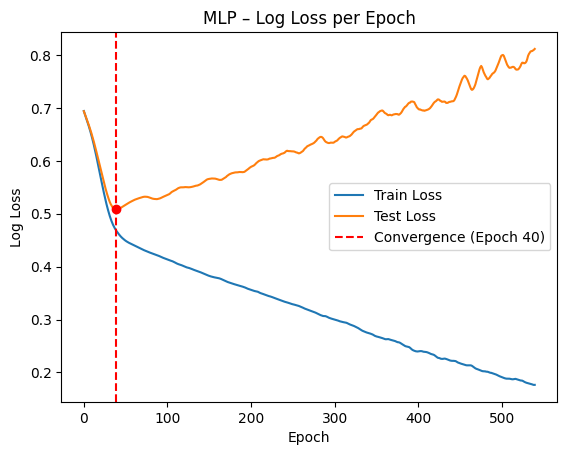


        MLP Final Metrics
Accuracy  : 0.7273
Precision : 0.6140
Recall    : 0.6364
F1 Score  : 0.6250
Best Epoch: 40
CO2       : 0.000027 kg


In [6]:
# ════════════════════════════════════════
#                MLP (GPU)
# ════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker
import warnings

warnings.filterwarnings('ignore')

# ── GPU Setup ───────────────────────────────────────────────────────────────
print("="*40)
print("         GPU Status")
print("="*40)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    print("GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print("GPU Available      : No — using CPU")

print(f"MLP runs on        : {device}")
print("="*40)

# ── Scale Data ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# ── Model ────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

# ── Init ─────────────────────────────────────────────────────────────────────
input_dim = X_train_tensor.shape[1]
model = MLP(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ── CodeCarbon ───────────────────────────────────────────────────────────────
tracker = EmissionsTracker(log_level="error")
tracker.start()

train_losses = []
test_losses = []

# ── Early Stopping Setup ────────────────────────────────────────────────────
patience = 500
best_loss = float('inf')
counter = 0
best_state = None
best_epoch = 0

# ── Training Loop ───────────────────────────────────────────────────────────
for epoch in range(5000):

    model.train()
    optimizer.zero_grad()

    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    # ── Evaluation ──
    model.eval()
    with torch.no_grad():
        train_probs = torch.sigmoid(model(X_train_tensor)).cpu().numpy()
        test_probs  = torch.sigmoid(model(X_test_tensor)).cpu().numpy()

    train_loss = log_loss(y_train, train_probs)
    test_loss  = log_loss(y_test, test_probs)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1:4d} — Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # ── Early Stopping + Best Epoch Tracking ──
    if test_loss < best_loss - 1e-6:
        best_loss = test_loss
        best_epoch = epoch
        counter = 0
        best_state = model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# ── Restore best model ───────────────────────────────────────────────────────
if best_state is not None:
    model.load_state_dict(best_state)

# ── Stop emissions tracker ───────────────────────────────────────────────────
emissions = tracker.stop()
print(f"\nCO2 Emissions: {emissions:.6f} kg")

# ── Final Metrics ────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_tensor)).cpu().numpy()

preds = (probs >= 0.5).astype(int)

accuracy  = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall    = recall_score(y_test, preds)
f1        = f1_score(y_test, preds)

# ── Plot with Convergence Line ───────────────────────────────────────────────
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.axvline(
    x=best_epoch,
    color='red',
    linestyle='--',
    label=f'Convergence (Epoch {best_epoch + 1})'
)

plt.scatter(best_epoch, best_loss, color='red', zorder=5)

plt.title("MLP – Log Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── Results ────────────────────────────────────────────────────────────────
print("\n" + "="*40)
print("        MLP Final Metrics")
print("="*40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"Best Epoch: {best_epoch + 1}")
print(f"CO2       : {emissions:.6f} kg")
print("="*40)

         GPU Status
GPU Available      : Yes
GPU Name           : Tesla T4
GPU Memory (GB)    : 15.64
Random Forest runs on : CPU (n_jobs=-1 uses all cores)
Tree   1 — Train Loss: 4.5788 | Test Loss: 11.7025
Tree   2 — Train Loss: 0.7947 | Test Loss: 6.0988
Tree   3 — Train Loss: 0.2729 | Test Loss: 3.8215
Tree   4 — Train Loss: 0.1598 | Test Loss: 3.1545
Tree   5 — Train Loss: 0.1506 | Test Loss: 2.2649
Tree   6 — Train Loss: 0.1447 | Test Loss: 1.8231
Tree   7 — Train Loss: 0.1451 | Test Loss: 1.8314
Tree   8 — Train Loss: 0.1441 | Test Loss: 1.6100
Tree   9 — Train Loss: 0.1401 | Test Loss: 1.1600
Tree  10 — Train Loss: 0.1400 | Test Loss: 0.9446
Tree  11 — Train Loss: 0.1377 | Test Loss: 0.9553
Tree  12 — Train Loss: 0.1396 | Test Loss: 0.7395
Tree  13 — Train Loss: 0.1400 | Test Loss: 0.7210
Tree  14 — Train Loss: 0.1389 | Test Loss: 0.7211
Tree  15 — Train Loss: 0.1371 | Test Loss: 0.7244
Tree  16 — Train Loss: 0.1374 | Test Loss: 0.7314
Tree  17 — Train Loss: 0.1352 | Test Loss:

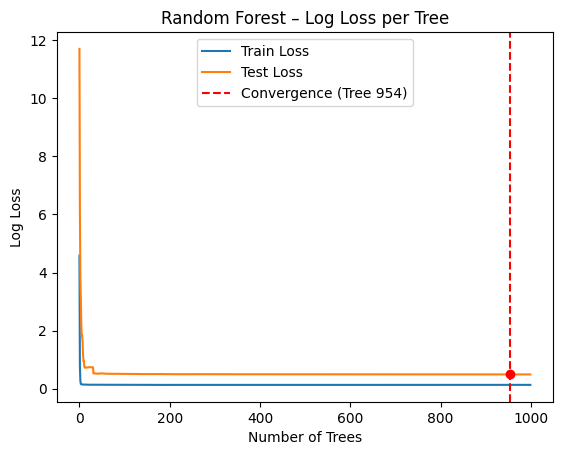


     Random Forest – Final Metrics
Accuracy           : 0.7338
Precision          : 0.6250
Recall             : 0.6364
F1 Score           : 0.6306
Convergence Tree   : 954
Min Train Loss     : 0.1293
Min Test  Loss     : 0.4890
CO2  Emissions     : 0.001604  kg CO2
   GHG Breakdown (Approximate)
CO2  (kg)          : 0.00144317
CH4  (kg)          : 0.00011225
N2O  (kg)          : 0.00004811
Total CO2eq (kg)   : 0.00160352


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import numpy as np
import warnings
import torch

warnings.filterwarnings('ignore')

# ── Check GPU Status ─────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"{'='*40}")

# ── Note: Random Forest runs on CPU (sklearn has no GPU support) ─────────────
print(f"Random Forest runs on : CPU (n_jobs=-1 uses all cores)")
print(f"{'='*40}")

# ── 1. Initialise CodeCarbon Emissions Tracker ───────────────────────────────
rf_tracker = EmissionsTracker(log_level="error")
rf_tracker.start()

rf_train_losses = []
rf_test_losses  = []

# ── 2. Train Random Forest; record loss per tree ─────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    warm_start=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

for n_tree in range(1, 1001):
    rf_model.set_params(n_estimators=n_tree)
    rf_model.fit(X_train, y_train)

    rf_train_proba = rf_model.predict_proba(X_train)
    rf_test_proba  = rf_model.predict_proba(X_test)

    rf_train_loss = log_loss(y_train, rf_train_proba)
    rf_test_loss  = log_loss(y_test,  rf_test_proba)

    rf_train_losses.append(rf_train_loss)
    rf_test_losses.append(rf_test_loss)

    print(f"Tree {n_tree:3d} — Train Loss: {rf_train_loss:.4f} | Test Loss: {rf_test_loss:.4f}")

# ── 3. Identify minimum-loss tree (convergence point) ────────────────────────
rf_min_tree       = np.argmin(rf_test_losses)
rf_min_test_loss  = rf_test_losses[rf_min_tree]
rf_min_train_loss = rf_train_losses[rf_min_tree]

print(f"\nConvergence Point  : Tree {rf_min_tree + 1}")
print(f"Min Train Loss     : {rf_min_train_loss:.4f}")
print(f"Min Test  Loss     : {rf_min_test_loss:.4f}")

# ── 4. Stop tracker; record CO2 emissions ────────────────────────────────────
rf_emissions = rf_tracker.stop()
print(f"CO2 Emissions      : {rf_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(rf_train_losses, label='Train Loss')
plt.plot(rf_test_losses,  label='Test Loss')
plt.axvline(x=rf_min_tree, color='red', linestyle='--', label=f'Convergence (Tree {rf_min_tree+1})')
plt.scatter(rf_min_tree, rf_min_test_loss, color='red', zorder=5)
plt.title("Random Forest – Log Loss per Tree")
plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
rf_y_pred = rf_model.predict(X_test)

rf_accuracy  = accuracy_score(y_test,  rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall    = recall_score(y_test,    rf_y_pred)
rf_f1        = f1_score(y_test,        rf_y_pred)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
rf_ghg_co2 = rf_emissions * 0.90
rf_ghg_ch4 = rf_emissions * 0.07
rf_ghg_n2o = rf_emissions * 0.03

print(f"\n{'='*40}")
print(f"     Random Forest – Final Metrics")
print(f"{'='*40}")
print(f"Accuracy           : {rf_accuracy:.4f}")
print(f"Precision          : {rf_precision:.4f}")
print(f"Recall             : {rf_recall:.4f}")
print(f"F1 Score           : {rf_f1:.4f}")
print(f"Convergence Tree   : {rf_min_tree + 1}")
print(f"Min Train Loss     : {rf_min_train_loss:.4f}")
print(f"Min Test  Loss     : {rf_min_test_loss:.4f}")
print(f"CO2  Emissions     : {rf_emissions:.6f}  kg CO2")
print(f"{'='*40}")
print(f"   GHG Breakdown (Approximate)")
print(f"{'='*40}")
print(f"CO2  (kg)          : {rf_ghg_co2:.8f}")
print(f"CH4  (kg)          : {rf_ghg_ch4:.8f}")
print(f"N2O  (kg)          : {rf_ghg_n2o:.8f}")
print(f"Total CO2eq (kg)   : {rf_emissions:.8f}")
print(f"{'='*40}")

warnings.filterwarnings('default')

         GPU Status
GPU Available      : Yes
GPU Name           : Tesla T4
GPU Memory (GB)    : 15.64
XGBoost runs on    : GPU (cuda)

Convergence Point  : Iteration 4
Min Train Loss     : 0.3511
Min Test  Loss     : 0.5054
CO2 Emissions      : 0.000002 kg CO2


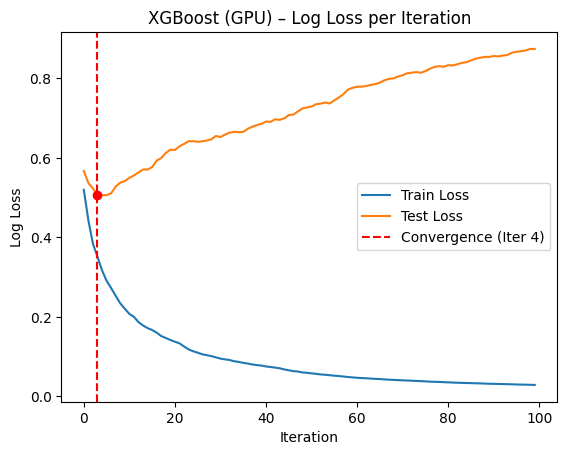


      XGBoost – Final Metrics
Accuracy           : 0.7143
Precision          : 0.5846
Recall             : 0.6909
F1 Score           : 0.6333
Convergence Iter   : 4
Min Train Loss     : 0.3511
Min Test  Loss     : 0.5054
CO2  Emissions     : 0.000002 kg CO2
   GHG Breakdown (Approximate)
CO2  (kg)          : 0.00000161
CH4  (kg)          : 0.00000013
N2O  (kg)          : 0.00000005
Total CO2eq (kg)   : 0.00000179


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import numpy as np
import warnings
import torch

warnings.filterwarnings('ignore')

# ── Check GPU Status ─────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

# ── 1. Initialise CodeCarbon Emissions Tracker ───────────────────────────────
xgb_tracker = EmissionsTracker(log_level="error")
xgb_tracker.start()

xgb_train_losses = []
xgb_test_losses  = []

# ── 2. Train XGBoost on GPU; record loss per iteration ───────────────────────
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# ── Get loss per iteration from eval results ──────────────────────────────────
xgb_results      = xgb_model.evals_result()
xgb_train_losses = xgb_results['validation_0']['logloss']
xgb_test_losses  = xgb_results['validation_1']['logloss']

# ── 3. Identify minimum-loss iteration (convergence point) ───────────────────
xgb_min_iter      = np.argmin(xgb_test_losses)
xgb_min_test_loss = xgb_test_losses[xgb_min_iter]
xgb_min_train_loss= xgb_train_losses[xgb_min_iter]

print(f"\nConvergence Point  : Iteration {xgb_min_iter + 1}")
print(f"Min Train Loss     : {xgb_min_train_loss:.4f}")
print(f"Min Test  Loss     : {xgb_min_test_loss:.4f}")

# ── 4. Stop tracker; record CO2 emissions ────────────────────────────────────
xgb_emissions = xgb_tracker.stop()
print(f"CO2 Emissions      : {xgb_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(xgb_train_losses, label='Train Loss')
plt.plot(xgb_test_losses,  label='Test Loss')
plt.axvline(x=xgb_min_iter, color='red', linestyle='--', label=f'Convergence (Iter {xgb_min_iter+1})')
plt.scatter(xgb_min_iter, xgb_min_test_loss, color='red', zorder=5)
plt.title("XGBoost (GPU) – Log Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
xgb_y_pred       = xgb_model.predict(X_test)
xgb_y_pred_proba = xgb_model.predict_proba(X_test)

xgb_accuracy  = accuracy_score(y_test,  xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall    = recall_score(y_test,    xgb_y_pred)
xgb_f1        = f1_score(y_test,        xgb_y_pred)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
xgb_ghg_co2 = xgb_emissions * 0.90
xgb_ghg_ch4 = xgb_emissions * 0.07
xgb_ghg_n2o = xgb_emissions * 0.03

print(f"\n{'='*40}")
print(f"      XGBoost – Final Metrics")
print(f"{'='*40}")
print(f"Accuracy           : {xgb_accuracy:.4f}")
print(f"Precision          : {xgb_precision:.4f}")
print(f"Recall             : {xgb_recall:.4f}")
print(f"F1 Score           : {xgb_f1:.4f}")
print(f"Convergence Iter   : {xgb_min_iter + 1}")
print(f"Min Train Loss     : {xgb_min_train_loss:.4f}")
print(f"Min Test  Loss     : {xgb_min_test_loss:.4f}")
print(f"CO2  Emissions     : {xgb_emissions:.6f} kg CO2")
print(f"{'='*40}")
print(f"   GHG Breakdown (Approximate)")
print(f"{'='*40}")
print(f"CO2  (kg)          : {xgb_ghg_co2:.8f}")
print(f"CH4  (kg)          : {xgb_ghg_ch4:.8f}")
print(f"N2O  (kg)          : {xgb_ghg_n2o:.8f}")
print(f"Total CO2eq (kg)   : {xgb_emissions:.8f}")
print(f"{'='*40}")

warnings.filterwarnings('default')

         GPU Status
GPU Available      : Yes
GPU Name           : Tesla T4
GPU Memory (GB)    : 15.64
AdaBoost runs on   : CPU (no GPU support in sklearn)
Estimator   1 — Train Loss: 0.6579 | Test Loss: 0.6464
Estimator   2 — Train Loss: 0.5570 | Test Loss: 0.5901
Estimator   3 — Train Loss: 0.5214 | Test Loss: 0.5410
Estimator   4 — Train Loss: 0.5015 | Test Loss: 0.5443
Estimator   5 — Train Loss: 0.5000 | Test Loss: 0.5380
Estimator   6 — Train Loss: 0.5016 | Test Loss: 0.5369
Estimator   7 — Train Loss: 0.5034 | Test Loss: 0.5408
Estimator   8 — Train Loss: 0.5021 | Test Loss: 0.5363
Estimator   9 — Train Loss: 0.5044 | Test Loss: 0.5436
Estimator  10 — Train Loss: 0.4972 | Test Loss: 0.5356
Estimator  11 — Train Loss: 0.5164 | Test Loss: 0.5552
Estimator  12 — Train Loss: 0.5172 | Test Loss: 0.5523
Estimator  13 — Train Loss: 0.5191 | Test Loss: 0.5537
Estimator  14 — Train Loss: 0.5149 | Test Loss: 0.5472
Estimator  15 — Train Loss: 0.5204 | Test Loss: 0.5525
Estimator  16 — Trai

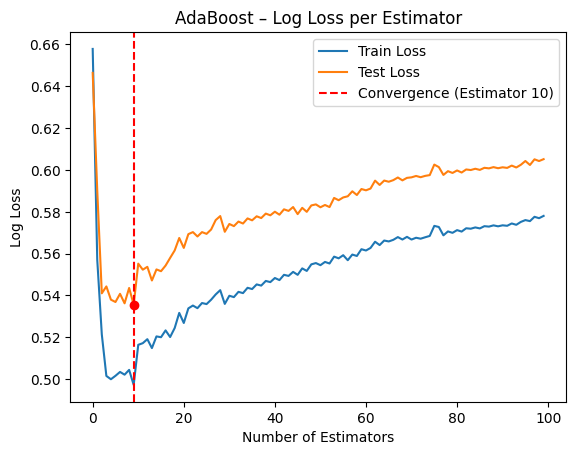


      AdaBoost – Final Metrics
Accuracy           : 0.7403
Precision          : 0.6271
Recall             : 0.6727
F1 Score           : 0.6491
Convergence Estim  : 10
Min Train Loss     : 0.4972
Min Test  Loss     : 0.5356
CO2  Emissions     : 0.000002 kg CO2
   GHG Breakdown (Approximate)
CO2  (kg)          : 0.00000165
CH4  (kg)          : 0.00000013
N2O  (kg)          : 0.00000005
Total CO2eq (kg)   : 0.00000183


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import numpy as np
import warnings
import torch

warnings.filterwarnings('ignore')

# ── Check GPU Status ─────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : CPU (no GPU support in sklearn)")
print(f"{'='*40}")

# ── 1. Initialise CodeCarbon Emissions Tracker ───────────────────────────────
ada_tracker = EmissionsTracker(log_level="error")
ada_tracker.start()

ada_train_losses = []
ada_test_losses  = []

# ── 2. Train AdaBoost; record loss per estimator ─────────────────────────────
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
ada_model.fit(X_train, y_train)

# ── Get loss per estimator using staged_predict_proba ────────────────────────
for ada_train_proba, ada_test_proba in zip(
    ada_model.staged_predict_proba(X_train),
    ada_model.staged_predict_proba(X_test)
):
    ada_train_loss = log_loss(y_train, ada_train_proba)
    ada_test_loss  = log_loss(y_test,  ada_test_proba)

    ada_train_losses.append(ada_train_loss)
    ada_test_losses.append(ada_test_loss)

    print(f"Estimator {len(ada_train_losses):3d} — Train Loss: {ada_train_loss:.4f} | Test Loss: {ada_test_loss:.4f}")

# ── 3. Identify minimum-loss estimator (convergence point) ───────────────────
ada_min_estimator  = np.argmin(ada_test_losses)
ada_min_test_loss  = ada_test_losses[ada_min_estimator]
ada_min_train_loss = ada_train_losses[ada_min_estimator]

print(f"\nConvergence Point  : Estimator {ada_min_estimator + 1}")
print(f"Min Train Loss     : {ada_min_train_loss:.4f}")
print(f"Min Test  Loss     : {ada_min_test_loss:.4f}")

# ── 4. Stop tracker; record CO2 emissions ────────────────────────────────────
ada_emissions = ada_tracker.stop()
print(f"CO2 Emissions      : {ada_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(ada_train_losses, label='Train Loss')
plt.plot(ada_test_losses,  label='Test Loss')
plt.axvline(x=ada_min_estimator, color='red', linestyle='--', label=f'Convergence (Estimator {ada_min_estimator+1})')
plt.scatter(ada_min_estimator, ada_min_test_loss, color='red', zorder=5)
plt.title("AdaBoost – Log Loss per Estimator")
plt.xlabel("Number of Estimators")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
ada_y_pred = ada_model.predict(X_test)

ada_accuracy  = accuracy_score(y_test,  ada_y_pred)
ada_precision = precision_score(y_test, ada_y_pred)
ada_recall    = recall_score(y_test,    ada_y_pred)
ada_f1        = f1_score(y_test,        ada_y_pred)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
ada_ghg_co2 = ada_emissions * 0.90
ada_ghg_ch4 = ada_emissions * 0.07
ada_ghg_n2o = ada_emissions * 0.03

print(f"\n{'='*40}")
print(f"      AdaBoost – Final Metrics")
print(f"{'='*40}")
print(f"Accuracy           : {ada_accuracy:.4f}")
print(f"Precision          : {ada_precision:.4f}")
print(f"Recall             : {ada_recall:.4f}")
print(f"F1 Score           : {ada_f1:.4f}")
print(f"Convergence Estim  : {ada_min_estimator + 1}")
print(f"Min Train Loss     : {ada_min_train_loss:.4f}")
print(f"Min Test  Loss     : {ada_min_test_loss:.4f}")
print(f"CO2  Emissions     : {ada_emissions:.6f} kg CO2")
print(f"{'='*40}")
print(f"   GHG Breakdown (Approximate)")
print(f"{'='*40}")
print(f"CO2  (kg)          : {ada_ghg_co2:.8f}")
print(f"CH4  (kg)          : {ada_ghg_ch4:.8f}")
print(f"N2O  (kg)          : {ada_ghg_n2o:.8f}")
print(f"Total CO2eq (kg)   : {ada_emissions:.8f}")
print(f"{'='*40}")

warnings.filterwarnings('default')

         GPU Status
GPU Available      : Yes
GPU Name           : Tesla T4
GPU Memory (GB)    : 15.64
Logistic Regression: GPU (cuda)
Epoch    1 — Train Loss: 0.7862 | Test Loss: 0.7496
Epoch    2 — Train Loss: 0.7850 | Test Loss: 0.7484
Epoch    3 — Train Loss: 0.7838 | Test Loss: 0.7473
Epoch    4 — Train Loss: 0.7826 | Test Loss: 0.7462
Epoch    5 — Train Loss: 0.7815 | Test Loss: 0.7450
Epoch    6 — Train Loss: 0.7803 | Test Loss: 0.7439
Epoch    7 — Train Loss: 0.7792 | Test Loss: 0.7428
Epoch    8 — Train Loss: 0.7780 | Test Loss: 0.7417
Epoch    9 — Train Loss: 0.7768 | Test Loss: 0.7406
Epoch   10 — Train Loss: 0.7757 | Test Loss: 0.7395
Epoch   11 — Train Loss: 0.7745 | Test Loss: 0.7384
Epoch   12 — Train Loss: 0.7734 | Test Loss: 0.7373
Epoch   13 — Train Loss: 0.7722 | Test Loss: 0.7362
Epoch   14 — Train Loss: 0.7711 | Test Loss: 0.7351
Epoch   15 — Train Loss: 0.7700 | Test Loss: 0.7340
Epoch   16 — Train Loss: 0.7688 | Test Loss: 0.7329
Epoch   17 — Train Loss: 0.7677 | 

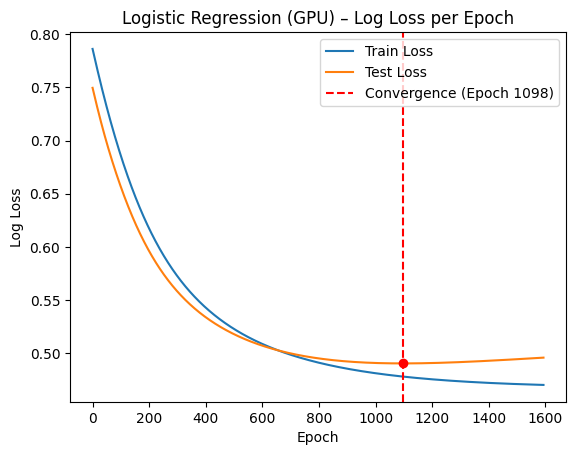


  Logistic Regression – Final Metrics
Accuracy           : 0.7662
Precision          : 0.6727
Recall             : 0.6727
F1 Score           : 0.6727
Convergence Epoch  : 1098
Min Train Loss     : 0.4780
Min Test  Loss     : 0.4904
CO2  Emissions     : 0.000024 kg CO2
   GHG Breakdown (Approximate)
CO2  (kg)          : 0.00002165
CH4  (kg)          : 0.00000168
N2O  (kg)          : 0.00000072
Total CO2eq (kg)   : 0.00002406


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# ════════════════════════════════════════
#       LOGISTIC REGRESSION (GPU)
# ════════════════════════════════════════
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker

warnings.filterwarnings('ignore')

# ── Check GPU Status ─────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Logistic Regression: {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Scale Data ───────────────────────────────────────────────────────────────
lr_scaler             = StandardScaler()
X_train_lr_scaled     = lr_scaler.fit_transform(X_train)
X_test_lr_scaled      = lr_scaler.transform(X_test)

# ── Convert to Tensors ───────────────────────────────────────────────────────
X_train_lr_tensor     = torch.tensor(X_train_lr_scaled, dtype=torch.float32).to(device)
X_test_lr_tensor      = torch.tensor(X_test_lr_scaled,  dtype=torch.float32).to(device)
y_train_lr_tensor     = torch.tensor(y_train.values,    dtype=torch.float32).to(device)
y_test_lr_tensor      = torch.tensor(y_test.values,     dtype=torch.float32).to(device)

# ── Define Logistic Regression as PyTorch Model ──────────────────────────────
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

lr_input_dim          = X_train_lr_tensor.shape[1]
lr_model              = LogisticRegressionModel(lr_input_dim).to(device)
lr_criterion          = torch.nn.BCELoss()
lr_optimizer          = torch.optim.Adam(lr_model.parameters(), lr=0.001)  # Adam

# ── 1. Initialise CodeCarbon Emissions Tracker ───────────────────────────────
lr_tracker            = EmissionsTracker(log_level="error")
lr_tracker.start()

lr_train_losses       = []
lr_test_losses        = []

# ── 2. Train on GPU; record loss per epoch ───────────────────────────────────
patience = 500              # stop if no improvement for 500 epochs
best_test_loss = float('inf')
counter = 0

lr_train_losses = []
lr_test_losses = []

best_model_state = None

for epoch in range(20000):
    lr_model.train()
    lr_optimizer.zero_grad()

    lr_y_pred = lr_model(X_train_lr_tensor).squeeze()
    lr_loss = lr_criterion(lr_y_pred, y_train_lr_tensor)

    lr_loss.backward()
    lr_optimizer.step()

    # ── Evaluation ──
    lr_model.eval()
    with torch.no_grad():
        lr_train_proba = lr_model(X_train_lr_tensor).squeeze().cpu().numpy()
        lr_test_proba  = lr_model(X_test_lr_tensor).squeeze().cpu().numpy()

    lr_train_loss = log_loss(y_train, lr_train_proba)
    lr_test_loss  = log_loss(y_test, lr_test_proba)

    lr_train_losses.append(lr_train_loss)
    lr_test_losses.append(lr_test_loss)

    print(f"Epoch {epoch+1:4d} — Train Loss: {lr_train_loss:.4f} | Test Loss: {lr_test_loss:.4f}")

    # ── Early Stopping Logic ──
    if lr_test_loss < best_test_loss - 1e-6:
        best_test_loss = lr_test_loss
        counter = 0
        best_model_state = lr_model.state_dict()  # save best model
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# ── Restore best model ──
if best_model_state is not None:
    lr_model.load_state_dict(best_model_state)

# ── 3. Identify minimum-loss epoch (convergence point) ───────────────────────
lr_min_epoch          = np.argmin(lr_test_losses)
lr_min_test_loss      = lr_test_losses[lr_min_epoch]
lr_min_train_loss     = lr_train_losses[lr_min_epoch]

print(f"\nConvergence Point  : Epoch {lr_min_epoch + 1}")
print(f"Min Train Loss     : {lr_min_train_loss:.4f}")
print(f"Min Test  Loss     : {lr_min_test_loss:.4f}")

# ── 4. Stop tracker; record CO2 emissions ────────────────────────────────────
lr_emissions          = lr_tracker.stop()
print(f"CO2 Emissions      : {lr_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(lr_train_losses, label='Train Loss')
plt.plot(lr_test_losses,  label='Test Loss')
plt.axvline(x=lr_min_epoch, color='red', linestyle='--', label=f'Convergence (Epoch {lr_min_epoch+1})')
plt.scatter(lr_min_epoch, lr_min_test_loss, color='red', zorder=5)
plt.title("Logistic Regression (GPU) – Log Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
lr_model.eval()
with torch.no_grad():
    lr_y_pred_proba       = lr_model(X_test_lr_tensor).squeeze().cpu().numpy()

lr_y_pred             = (lr_y_pred_proba >= 0.5).astype(int)
lr_accuracy           = accuracy_score(y_test,  lr_y_pred)
lr_precision          = precision_score(y_test, lr_y_pred)
lr_recall             = recall_score(y_test,    lr_y_pred)
lr_f1                 = f1_score(y_test,        lr_y_pred)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
lr_ghg_co2            = lr_emissions * 0.90
lr_ghg_ch4            = lr_emissions * 0.07
lr_ghg_n2o            = lr_emissions * 0.03

print(f"\n{'='*40}")
print(f"  Logistic Regression – Final Metrics")
print(f"{'='*40}")
print(f"Accuracy           : {lr_accuracy:.4f}")
print(f"Precision          : {lr_precision:.4f}")
print(f"Recall             : {lr_recall:.4f}")
print(f"F1 Score           : {lr_f1:.4f}")
print(f"Convergence Epoch  : {lr_min_epoch + 1}")
print(f"Min Train Loss     : {lr_min_train_loss:.4f}")
print(f"Min Test  Loss     : {lr_min_test_loss:.4f}")
print(f"CO2  Emissions     : {lr_emissions:.6f} kg CO2")
print(f"{'='*40}")
print(f"   GHG Breakdown (Approximate)")
print(f"{'='*40}")
print(f"CO2  (kg)          : {lr_ghg_co2:.8f}")
print(f"CH4  (kg)          : {lr_ghg_ch4:.8f}")
print(f"N2O  (kg)          : {lr_ghg_n2o:.8f}")
print(f"Total CO2eq (kg)   : {lr_emissions:.8f}")
print(f"{'='*40}")

warnings.filterwarnings('default')

         GPU Status
GPU Available      : Yes
GPU Name           : Tesla T4
GPU Memory (GB)    : 15.64
KNN runs on        : GPU (cuML)
Data size:     61 — Train Loss: 0.4807 | Test Loss: 0.9824
Data size:     90 — Train Loss: 0.4880 | Test Loss: 0.7804
Data size:    119 — Train Loss: 0.4099 | Test Loss: 0.8309
Data size:    148 — Train Loss: 0.3929 | Test Loss: 1.1897
Data size:    177 — Train Loss: 0.3859 | Test Loss: 1.1714

Early stopping triggered at data size 177

Convergence Point  : Data size 90
Min Train Loss     : 0.4880
Min Test  Loss     : 0.7804
CO2 Emissions      : 0.000004 kg CO2


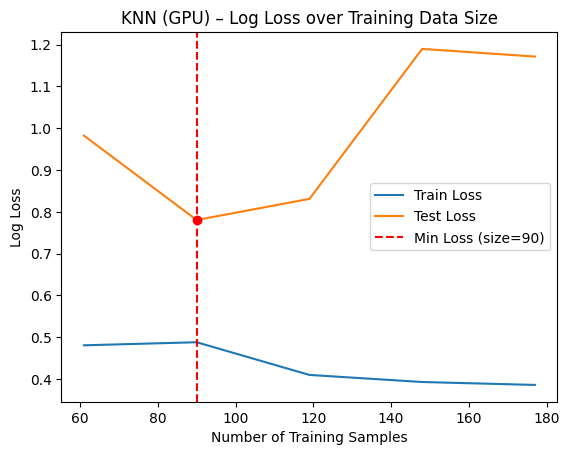


         KNN – Final Metrics
Accuracy           : 0.6623
Precision          : 0.5246
Recall             : 0.5818
F1 Score           : 0.5517
Min Train Loss     : 0.4880
Min Test  Loss     : 0.7804
CO2  Emissions     : 0.000004 kg CO2
   GHG Breakdown (Approximate)
CO2  (kg)          : 0.00000356
CH4  (kg)          : 0.00000028
N2O  (kg)          : 0.00000012
Total CO2eq (kg)   : 0.00000396


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
# ════════════════════════════════════════
#            KNN (GPU - cuML)
# ════════════════════════════════════════
import cudf
import cupy as cp
from cuml.neighbors import KNeighborsClassifier as cuKNN
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import numpy as np
import warnings
import torch

warnings.filterwarnings('ignore')

# ── Check GPU Status ─────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"KNN runs on        : {'GPU (cuML)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

# ── Convert to GPU format ────────────────────────────────────────────────────
X_train_knn_gpu = cudf.DataFrame(X_train.values.astype(np.float32))
X_test_knn_gpu  = cudf.DataFrame(X_test.values.astype(np.float32))
y_train_knn_gpu = cudf.Series(y_train.values.astype(np.int32))
y_test_knn_gpu  = cudf.Series(y_test.values.astype(np.int32))

# ── 1. Initialise CodeCarbon Emissions Tracker ───────────────────────────────
knn_tracker = EmissionsTracker(log_level="error")
knn_tracker.start()

knn_train_losses = []
knn_test_losses  = []

# ── 2. KNN learning curve with early stopping ───────────────────────────────

knn_data_sizes = np.linspace(0.1, 1.0, 20)

patience = 3  # stop if no improvement for 3 consecutive sizes
best_test_loss = float('inf')
counter = 0

knn_train_losses = []
knn_test_losses  = []

best_size_index = 0

for i, knn_size in enumerate(knn_data_sizes):
    knn_n_samples = int(len(X_train) * knn_size)

    X_train_knn_partial = X_train_knn_gpu.iloc[:knn_n_samples]
    y_train_knn_partial = y_train_knn_gpu.iloc[:knn_n_samples]

    knn_model = cuKNN(n_neighbors=5)
    knn_model.fit(X_train_knn_partial, y_train_knn_partial)

    knn_train_proba = knn_model.predict_proba(X_train_knn_partial).to_numpy()
    knn_test_proba  = knn_model.predict_proba(X_test_knn_gpu).to_numpy()

    knn_train_loss = log_loss(y_train[:knn_n_samples], knn_train_proba)
    knn_test_loss  = log_loss(y_test, knn_test_proba)

    knn_train_losses.append(knn_train_loss)
    knn_test_losses.append(knn_test_loss)

    print(f"Data size: {knn_n_samples:6d} — Train Loss: {knn_train_loss:.4f} | Test Loss: {knn_test_loss:.4f}")

    # ── Early stopping logic (on best test loss) ──
    if knn_test_loss < best_test_loss - 1e-6:
        best_test_loss = knn_test_loss
        counter = 0
        best_size_index = i
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at data size {knn_n_samples}")
        break

# ── 3. Identify minimum-loss point (convergence point) ───────────────────────
knn_min_point = best_size_index
knn_min_test_loss  = knn_test_losses[knn_min_point]
knn_min_train_loss = knn_train_losses[knn_min_point]
knn_min_size       = int(len(X_train) * knn_data_sizes[knn_min_point])

print(f"\nConvergence Point  : Data size {knn_min_size}")
print(f"Min Train Loss     : {knn_min_train_loss:.4f}")
print(f"Min Test  Loss     : {knn_min_test_loss:.4f}")

# ── 4. Stop tracker; record CO2 emissions ────────────────────────────────────
knn_emissions = knn_tracker.stop()
print(f"CO2 Emissions      : {knn_emissions:.6f} kg CO2")

# ── FIXED PLOT (handles early stopping) ─────────────────────────────────────

knn_x_axis = [int(len(X_train) * s) for s in knn_data_sizes]

# IMPORTANT: match lengths after early stopping
knn_x_axis = knn_x_axis[:len(knn_train_losses)]

plt.figure()
plt.plot(knn_x_axis, knn_train_losses, label='Train Loss')
plt.plot(knn_x_axis, knn_test_losses,  label='Test Loss')

plt.axvline(
    x=knn_x_axis[knn_min_point],
    color='red',
    linestyle='--',
    label=f'Min Loss (size={knn_min_size})'
)

plt.scatter(
    knn_x_axis[knn_min_point],
    knn_min_test_loss,
    color='red',
    zorder=5
)

plt.title("KNN (GPU) – Log Loss over Training Data Size")
plt.xlabel("Number of Training Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── 5. Train final model on full data for metrics ────────────────────────────
knn_final_model = cuKNN(n_neighbors=5)
knn_final_model.fit(X_train_knn_gpu, y_train_knn_gpu)

knn_y_pred_proba = knn_final_model.predict_proba(X_test_knn_gpu).to_numpy()
knn_y_pred       = (knn_y_pred_proba[:, 1] >= 0.5).astype(int)

knn_accuracy  = accuracy_score(y_test,  knn_y_pred)
knn_precision = precision_score(y_test, knn_y_pred)
knn_recall    = recall_score(y_test,    knn_y_pred)
knn_f1        = f1_score(y_test,        knn_y_pred)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
knn_ghg_co2 = knn_emissions * 0.90
knn_ghg_ch4 = knn_emissions * 0.07
knn_ghg_n2o = knn_emissions * 0.03

print(f"\n{'='*40}")
print(f"         KNN – Final Metrics")
print(f"{'='*40}")
print(f"Accuracy           : {knn_accuracy:.4f}")
print(f"Precision          : {knn_precision:.4f}")
print(f"Recall             : {knn_recall:.4f}")
print(f"F1 Score           : {knn_f1:.4f}")
print(f"Min Train Loss     : {knn_min_train_loss:.4f}")
print(f"Min Test  Loss     : {knn_min_test_loss:.4f}")
print(f"CO2  Emissions     : {knn_emissions:.6f} kg CO2")
print(f"{'='*40}")
print(f"   GHG Breakdown (Approximate)")
print(f"{'='*40}")
print(f"CO2  (kg)          : {knn_ghg_co2:.8f}")
print(f"CH4  (kg)          : {knn_ghg_ch4:.8f}")
print(f"N2O  (kg)          : {knn_ghg_n2o:.8f}")
print(f"Total CO2eq (kg)   : {knn_emissions:.8f}")
print(f"{'='*40}")

warnings.filterwarnings('default')

In [12]:
summary_data = [
    {
        "Model": "MLP",
        "Accuracy": f"{accuracy*100:.3f}%",
        "Precision": f"{precision*100:.3f}%",
        "Recall": f"{recall*100:.3f}%",
        "F1 Score": f"{f1*100:.3f}%",
        "Best Epoch": best_epoch + 1,
        "Min Train Loss": None,
        "Min Test Loss": None,
        "CO2 (kg)": emissions
    },
    {
        "Model": "Random Forest",
        "Accuracy": f"{rf_accuracy*100:.3f}%",
        "Precision": f"{rf_precision*100:.3f}%",
        "Recall": f"{rf_recall*100:.3f}%",
        "F1 Score": f"{rf_f1*100:.3f}%",
        "Best Epoch": rf_min_tree + 1,
        "Min Train Loss": rf_min_train_loss,
        "Min Test Loss": rf_min_test_loss,
        "CO2 (kg)": rf_emissions
    },
    {
        "Model": "XGBoost",
        "Accuracy": f"{xgb_accuracy*100:.3f}%",
        "Precision": f"{xgb_precision*100:.3f}%",
        "Recall": f"{xgb_recall*100:.3f}%",
        "F1 Score": f"{xgb_f1*100:.3f}%",
        "Best Epoch": xgb_min_iter + 1,
        "Min Train Loss": xgb_min_train_loss,
        "Min Test Loss": xgb_min_test_loss,
        "CO2 (kg)": xgb_emissions
    },
    {
        "Model": "AdaBoost",
        "Accuracy": f"{ada_accuracy*100:.3f}%",
        "Precision": f"{ada_precision*100:.3f}%",
        "Recall": f"{ada_recall*100:.3f}%",
        "F1 Score": f"{ada_f1*100:.3f}%",
        "Best Epoch": ada_min_estimator + 1,
        "Min Train Loss": ada_min_train_loss,
        "Min Test Loss": ada_min_test_loss,
        "CO2 (kg)": ada_emissions
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": f"{lr_accuracy*100:.3f}%",
        "Precision": f"{lr_precision*100:.3f}%",
        "Recall": f"{lr_recall*100:.3f}%",
        "F1 Score": f"{lr_f1*100:.3f}%",
        "Best Epoch": lr_min_epoch + 1,
        "Min Train Loss": lr_min_train_loss,
        "Min Test Loss": lr_min_test_loss,
        "CO2 (kg)": lr_emissions
    },
    {
        "Model": "KNN",
        "Accuracy": f"{knn_accuracy*100:.3f}%",
        "Precision": f"{knn_precision*100:.3f}%",
        "Recall": f"{knn_recall*100:.3f}%",
        "F1 Score": f"{knn_f1*100:.3f}%",
        "Best Epoch": knn_min_size,
        "Min Train Loss": knn_min_train_loss,
        "Min Test Loss": knn_min_test_loss,
        "CO2 (kg)": knn_emissions
    }
]

df_summary = pd.DataFrame(summary_data)

# ── Display table ───────────────────────────────────────────────────────────
print("\n" + "="*80)
print("               MODEL COMPARISON TABLE")
print("="*80)
print(df_summary)

# ── Optional: sort by best model (F1 Score) ─────────────────────────────────
df_sorted = df_summary.sort_values(by="F1 Score", ascending=False)

print("\n" + "="*80)
print("            SORTED BY F1 SCORE")
print("="*80)
print(df_sorted)

# ── Optional: save to CSV ───────────────────────────────────────────────────
df_summary.to_csv("model_comparison.csv", index=False)


               MODEL COMPARISON TABLE
                 Model Accuracy Precision   Recall F1 Score  Best Epoch  \
0                  MLP  72.727%   61.404%  63.636%  62.500%          40   
1        Random Forest  73.377%   62.500%  63.636%  63.063%         954   
2              XGBoost  71.429%   58.462%  69.091%  63.333%           4   
3             AdaBoost  74.026%   62.712%  67.273%  64.912%          10   
4  Logistic Regression  76.623%   67.273%  67.273%  67.273%        1098   
5                  KNN  66.234%   52.459%  58.182%  55.172%          90   

   Min Train Loss  Min Test Loss  CO2 (kg)  
0             NaN            NaN  0.000027  
1        0.129263       0.489041  0.001604  
2        0.351083       0.505449  0.000002  
3        0.497239       0.535589  0.000002  
4        0.477969       0.490369  0.000024  
5        0.488041       0.780435  0.000004  

            SORTED BY F1 SCORE
                 Model Accuracy Precision   Recall F1 Score  Best Epoch  \
4  Logistic R

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:

# ── Check class balance ───────────────────────────────────────────────
class_counts = np.bincount(y_train)
imbalance_ratio = min(class_counts) / max(class_counts)

# Rule of thumb:
# > 0.8 → balanced
# ≤ 0.8 → imbalanced
is_balanced = imbalance_ratio > 0.8

print("Class balance ratio:", imbalance_ratio)
print("Dataset is balanced:", is_balanced)

# ── Helper function ────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 == 0 or co2 is None or np.isnan(co2):
        return np.nan
    return score * np.log1p(1 / (co2 + 1e-12))

# ── Collect CES for each model ────────────────────────────────────────
ces_data = []

models = [
    ("MLP", accuracy, f1, emissions),
    ("Random Forest", rf_accuracy, rf_f1, rf_emissions),
    ("XGBoost", xgb_accuracy, xgb_f1, xgb_emissions),
    ("AdaBoost", ada_accuracy, ada_f1, ada_emissions),
    ("Logistic Regression", lr_accuracy, lr_f1, lr_emissions),
    ("KNN", knn_accuracy, knn_f1, knn_emissions)
]

for name, acc, f1, co2 in models:

    if is_balanced:
        metric = acc
    else:
        metric = f1

    ces = compute_ces(metric, co2)

    ces_data.append({
        "Model": name,
        "Metric Used": "Accuracy" if is_balanced else "F1 Score",
        "Score": metric,
        "CO2 (kg)": co2,
        "CES": ces
    })

# ── Create DataFrame ──────────────────────────────────────────────────
df_ces = pd.DataFrame(ces_data)

# ── Sort by CES (best efficiency first) ──────────────────────────────
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display results ───────────────────────────────────────────────────
print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted)

# ── Optional save ─────────────────────────────────────────────────────
df_ces_sorted.to_csv("ces_scores.csv", index=False)

Class balance ratio: 0.5311720698254364
Dataset is balanced: False

           CONVERGENCE EFFICIENCY SCORE (CES)
                 Model Metric Used     Score  CO2 (kg)       CES
3             AdaBoost    F1 Score  0.649123  0.000002  8.575645
2              XGBoost    F1 Score  0.633333  0.000002  8.381879
4  Logistic Regression    F1 Score  0.672727  0.000024  7.154447
5                  KNN    F1 Score  0.551724  0.000004  6.862899
0                  MLP    F1 Score  0.625000  0.000027  6.585587
1        Random Forest    F1 Score  0.630631  0.001604  4.059466


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
import pandas as pd
import numpy as np

# ── Check class balance ───────────────────────────────────────────────
class_counts = np.bincount(y_train)
imbalance_ratio = min(class_counts) / max(class_counts)

# Rule of thumb:
# > 0.8 → balanced
# ≤ 0.8 → imbalanced
is_balanced = imbalance_ratio > 0.8

print("Class balance ratio:", imbalance_ratio)
print("Dataset is balanced:", is_balanced)

# ── Helper function ────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 == 0 or co2 is None or np.isnan(co2):
        return np.nan
    return score * np.log1p(1 / (co2 + 1e-12))

# ── Collect CES for each model ────────────────────────────────────────
ces_data = []

models = [
    ("MLP", accuracy, f1, emissions),
    ("Random Forest", rf_accuracy, rf_f1, rf_emissions),
    ("XGBoost", xgb_accuracy, xgb_f1, xgb_emissions),
    ("AdaBoost", ada_accuracy, ada_f1, ada_emissions),
    ("Logistic Regression", lr_accuracy, lr_f1, lr_emissions),
    ("KNN", knn_accuracy, knn_f1, knn_emissions)
]

for name, acc, f1, co2 in models:

    if is_balanced:
        metric = acc
    else:
        metric = f1

    ces = compute_ces(metric, co2)

    ces_data.append({
        "Model": name,
        "Metric Used": "Accuracy" if is_balanced else "F1 Score",
        "Score": metric,
        "CO2 (kg)": co2,
        "CES": ces
    })

# ── Create DataFrame ──────────────────────────────────────────────────
df_ces = pd.DataFrame(ces_data)

# ── Sort by CES (best efficiency first) ──────────────────────────────
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display results ───────────────────────────────────────────────────
print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted)

# ── Optional save ─────────────────────────────────────────────────────
df_ces_sorted.to_csv("ces_scores.csv", index=False)

Class balance ratio: 0.5311720698254364
Dataset is balanced: False

           CONVERGENCE EFFICIENCY SCORE (CES)
                 Model Metric Used     Score  CO2 (kg)       CES
3             AdaBoost    F1 Score  0.649123  0.000002  8.575645
2              XGBoost    F1 Score  0.633333  0.000002  8.381879
4  Logistic Regression    F1 Score  0.672727  0.000024  7.154447
5                  KNN    F1 Score  0.551724  0.000004  6.862899
0                  MLP    F1 Score  0.551724  0.000027  5.813484
1        Random Forest    F1 Score  0.630631  0.001604  4.059466


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


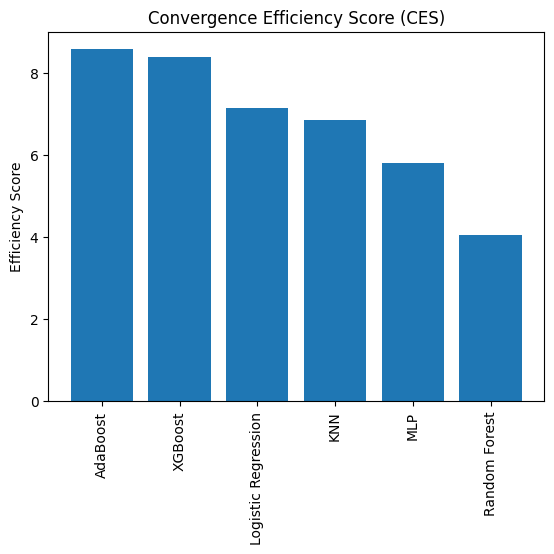

In [16]:
plt.figure()
plt.bar(df_ces_sorted["Model"], df_ces_sorted["CES"])
plt.xticks(rotation=90)
plt.title("Convergence Efficiency Score (CES)")
plt.ylabel("Efficiency Score")
plt.show()